# Capítulo 10 - Trabalhando com Dados

Página 179-202

## Redimensionamento

Vamos considerar o exemplo abaixo em que temos os dados de altura e peso de algumas pessoas, sendo que a altura temos disponível em duas unidades: polegadas e centimetros.

Se tratarmos os pares `(altura, peso)` como pontos de um espaço bidimensional e calcularmos a distância euclidiana de cada uma das pessoas para outra, primeiro usando a altura em polegada e depois em centimetros, veremos que os pares de vizinhos mais próximos mudam:

In [34]:
import pandas as pd

df = pd.DataFrame(
    columns=['altura_in', 'altura_cm', 'peso_lb'],
    data=  [[         63,         160,       150],
            [         67,       170.2,       160],
            [         70,       177.8,       171]],
    index=['A','B','C'])
df

,altura_in,altura_cm,peso_lb
A,63,160.0,150
B,67,170.2,160
C,70,177.8,171


In [35]:
from modulo_python_livro import distance

a_to_b_in = distance(df.loc['A', ['altura_in','peso_lb']], df.loc['B', ['altura_in','peso_lb']])
a_to_c_in = distance(df.loc['A', ['altura_in','peso_lb']], df.loc['C', ['altura_in','peso_lb']])
b_to_c_in = distance(df.loc['B', ['altura_in','peso_lb']], df.loc['C', ['altura_in','peso_lb']])

print(f"[Altura (in), peso (kg)]\ndist_AB: {a_to_b_in}\ndist_AC: {a_to_c_in}\ndist_BC: {b_to_c_in}")

[Altura (in), peso (kg)]
dist_AB: 10.770329614269007
dist_AC: 22.135943621178654
dist_BC: 11.40175425099138


In [36]:
a_to_b_cm = distance(df.loc['A', ['altura_cm','peso_lb']], df.loc['B', ['altura_cm','peso_lb']])
a_to_c_cm = distance(df.loc['A', ['altura_cm','peso_lb']], df.loc['C', ['altura_cm','peso_lb']])
b_to_c_cm = distance(df.loc['B', ['altura_cm','peso_lb']], df.loc['C', ['altura_cm','peso_lb']])

print(f"[Altura (cm), peso (kg)]\ndist_AB: {a_to_b_cm}\ndist_AC: {a_to_c_cm}\ndist_BC: {b_to_c_cm}")

[Altura (cm), peso (kg)]
dist_AB: 14.284257068535268
dist_AC: 27.52889391167034
dist_BC: 13.370115930686627


A fórmula para calcular a distância euclidiana entre os pontos $P$ e $Q$ é:

$$ d(P,Q) = \sqrt{{(x_Q - x_P)}^2 + {(y_Q - y_P)}^2}$$

ou seja, estamos somando o quadrado das diferenças em cada dimensão, o que siginifica que **a dimensão com os maiores números vai dominar a distância**.

Se alterações na unidade mudam o resultado, então o que estamos medindo não é a distância entre pontos, mas qual a escala se destaca mais.

Nesses casos, devemos **redimensionar** os dados para que cada dimensão tenha **média 0** e **desvio-padrão 1**. Assim, eliminamos as unidades, pois cada dimensão é convertida em "desvios-padrão da média". Esse redimensionamento é a padronização ($z$-score):

$$ z = \frac{x - \mu}{\sigma} $$

In [37]:
# from typing import Tuple
from modulo_python_livro import vector_mean, standard_deviation

def scale(data: list[list]) -> tuple[list, list]:
    """
    Retorna media e desvio padra de cada dimensao.
    Cada vetor de `data` traz as componentes em cada uma das dimensoes.
    """

    # considera que todos os vetores tem a mesma dimensao
    dim = len(data[0])

    # vetor com as medias de cada dimensao de `data`
    means  = vector_mean(data)

    # vetor com os desvios-padrao de cada dimensao de `data`
    # pega i-dimensao de cada vetor e calcula desvio-padrao da dimensao
    # faz isso em todas as dimensoes
    stdevs = [standard_deviation([vector[i] for vector in data])
              for i in range(dim)]

    return means, stdevs

vectors_1         = [[-3,-1,1], [-1,0,1], [1,1,1]]
means_1, stdevs_1 = scale(vectors_1)
print(f"medias: \t{means_1}\ndesvios-padra: \t{stdevs_1}")

medias: 	[-1.0, 0.0, 1.0]
desvios-padra: 	[2.0, 1.0, 0.0]


In [38]:
vectors_2         = [[1,2,3], [1,2,3], [1,2,3], [1,2,3]]
means_2, stdevs_2 = scale(vectors_2)
print(f"medias: \t{means_2}\ndesvios-padra: \t{stdevs_2}")

medias: 	[1.0, 2.0, 3.0]
desvios-padra: 	[0.0, 0.0, 0.0]


In [39]:
vectors_3         = [[1,2,3,4], [4,3,2,1], [2,4,1,3], [3,1,4,2]]
means_3, stdevs_3 = scale(vectors_3)
print(f"medias: \t{means_3}\ndesvios-padra: \t{stdevs_3}")

medias: 	[2.5, 2.5, 2.5, 2.5]
desvios-padra: 	[1.2909944487358056, 1.2909944487358056, 1.2909944487358056, 1.2909944487358056]


In [40]:
def rescale(data: list[list]) -> list[list]:
    """
    Redimensiona os dados de entrada para que cada dimensao tenha media 0 e desvio padrao 1.
    Deixa a dimensao como esta se o desvio-padrao for zero.
    """

    dim           = len(data[0])         # considera que todos os vetores tem a mesma dimensao
    means, stdevs = scale(data)          # calcula media e desvio-padra de cada dimensao
    rescaled      = [v[:] for v in data] # faz copia dos vetores

    # percorre cada um dos vetores de `data`
    for v in rescaled:
        for i in range(dim):

            # se a i-dimensao tem desvio-padrao diferente de zero
            if stdevs[i] > 0:
                # padroniza essa componente do vetor `v`
                v[i] = (v[i] - means[i]) / stdevs[i]

    return rescaled

vector_1_rescalad = rescale(vectors_1)
means_1, stdevs_1 = scale(rescale(vectors_1))
print(f"vetor original: {vectors_1}\nvetores reescalado: {vector_1_rescalad}")
print(f"medias: \t{means_1}\ndesvios-padra: \t{stdevs_1}")


vetor original: [[-3, -1, 1], [-1, 0, 1], [1, 1, 1]]
vetores reescalado: [[-1.0, -1.0, 1], [0.0, 0.0, 1], [1.0, 1.0, 1]]
medias: 	[0.0, 0.0, 1.0]
desvios-padra: 	[1.0, 1.0, 0.0]


In [41]:
vector_2_rescalad = rescale(vectors_2)
means_2, stdevs_2 = scale(rescale(vectors_2))
print(f"vetor original: {vectors_2}\nvetores reescalado: {vector_2_rescalad}")
print(f"medias: \t{means_2}\ndesvios-padra: \t{stdevs_2}")

vetor original: [[1, 2, 3], [1, 2, 3], [1, 2, 3], [1, 2, 3]]
vetores reescalado: [[1, 2, 3], [1, 2, 3], [1, 2, 3], [1, 2, 3]]
medias: 	[1.0, 2.0, 3.0]
desvios-padra: 	[0.0, 0.0, 0.0]


In [42]:
vector_3_rescalad = rescale(vectors_3)
means_3, stdevs_3 = scale(rescale(vectors_3))
print(f"vetor original: {vectors_3}\nvetores reescalado: {vector_3_rescalad}")
print(f"medias: \t{means_3}\ndesvios-padra: \t{stdevs_3}")

vetor original: [[1, 2, 3, 4], [4, 3, 2, 1], [2, 4, 1, 3], [3, 1, 4, 2]]
vetores reescalado: [[-1.161895003862225, -0.3872983346207417, 0.3872983346207417, 1.161895003862225], [1.161895003862225, 0.3872983346207417, -0.3872983346207417, -1.161895003862225], [-0.3872983346207417, 1.161895003862225, -1.161895003862225, 0.3872983346207417], [0.3872983346207417, -1.161895003862225, 1.161895003862225, -0.3872983346207417]]
medias: 	[0.0, 0.0, 0.0, 0.0]
desvios-padra: 	[1.0, 1.0, 1.0, 1.0]


## Redução de Dimensionalidade

Usamos a _análise de componente principal_ (PCA) para reduzir o número de dimensões que temos inicialmente, para um número de dimensões que concentre a maior variação possível dos dados.

Considerando o caso abaixo, por exemplo, a maior parte da variação nos dados parece estar em uma única dimensão que não corresponde ao eixo $x$ nem ao eixo $y$.

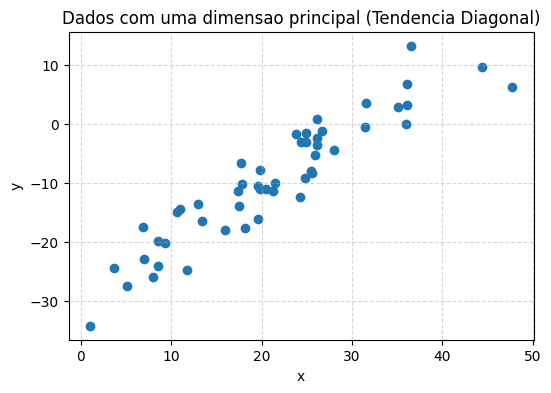

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# gera dados correlacionados simulando uma diagonal
mean = [20, -10]
cov  = [[150, 140], [140, 150]] # alta covariancia positiva para criar a diagonal
x, y = np.random.multivariate_normal(mean, cov, 50).T

plt.figure(figsize=(6, 4))
plt.scatter(x, y)

plt.title("Dados com uma dimensao principal (Tendencia Diagonal)")
plt.xlabel("x")
plt.ylabel("y")
# plt.xlim(-50,50)
# plt.ylim(-50,50)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Primeiro devemos **"centralizar os dados"**, subtraindo de cada dimensão sua média, para que a nova média seja zero.

Se não fizermos isso, a direção de maior "variação" seria apontada para a média e não para a dispersão. Se os dados estão fora da origem, o vetor que vai da origem até o "centro" dos dados domina a variação.

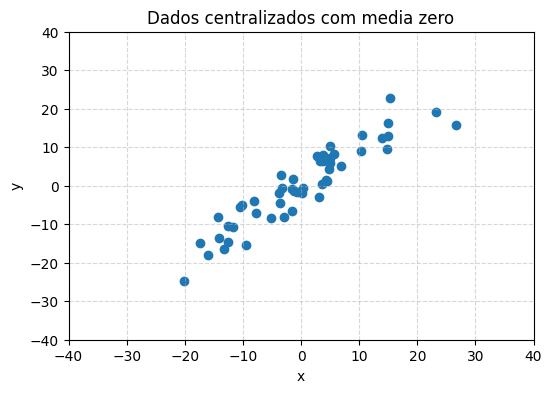

In [100]:
from modulo_python_livro import mean

x_1 = x - mean(x)
y_1 = y - mean(y)

plt.figure(figsize=(6, 4))
plt.scatter(x_1, y_1)

plt.title("Dados centralizados com media zero")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

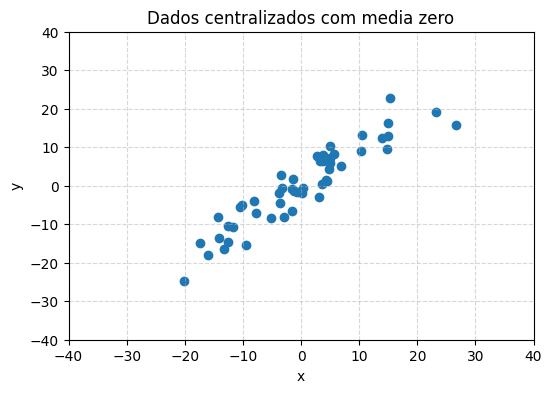

In [101]:
from modulo_python_livro import vector_subtract

def de_mean_vectors(data: list[list]) -> list[list]:
    """
    Centraliza os dados para que todas as dimensoes tenham media 0.
    """
    mean = vector_mean(data)
    return [vector_subtract(v, mean) for v in data]

# ao inves de uma lista com 2 listas (uma para cada eixo) com N elementos cada
# agora tenho uma lista com N listas (uma para cada ponto) com 2 elementos cada
dados_iniciais      = [list(i) for i in zip(x,y)]
dados_centralizados = de_mean_vectors(dados_iniciais)
x_1, y_1            = list(zip(*dados_centralizados))

plt.figure(figsize=(6, 4))
plt.scatter(x_1, y_1)

plt.title("Dados centralizados com media zero")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Em segundo lugar, agora que temos uma matriz (conjunto de pontos) com média redefinida, queremos determinar **qual a direção que captura a maior variação nos dados**.

Primeiro precisamos de uma função que determine a direção de um vetor $\overrightarrow{w}$ qualquer, ou seja, uma função que o normalize.

$$ \hat{w} = \frac{\overrightarrow{w}}{|\overrightarrow{w}|} $$

In [102]:
from modulo_python_livro import magnitude, dot

def direction(w: list) -> list:
    """
    Normaliza um vetor.
    Gera vetor de modulo 1 que indica a direcao do vetor
    """
    mag = magnitude(w)
    return [w_i / mag for w_i in w]

E depois calculamos a variação do conjunto de dados na direção desse vetor $\hat{w}$. Como os dados foram centralizados (possuem média zero), se calcularmos a soma dos quadrados da projeção de cada ponto sobre esse versor, teremos a medida do quanto a distribuição se afasta da origem, ao longo dessa direção. Então, temos a **variância direcional**:

$$ \text{variância direcional}(w) = \sum_i (x_i \cdot \hat{w})^2 $$

In [103]:
def directional_variance(data: list[list], w: list) -> float:
    """
    Retorna a variacao de v na direcao de w
    """
    w_dir = direction(w)
    return sum(dot(v, w_dir) ** 2 for v in data)

Agora temos um problema de maximização, queremos encontrar a direção que maximiza a variação dos dados. E para isso usaremos o gradiente descendente.

Conhecemos a variância dos dados, mas vamos fazer primeiro para um único ponto. Então o gradiente é:

$$ \nabla (x_i \cdot \hat{w})^2 = \frac{\partial (x_i \cdot \hat{w})^2}{\partial w} $$

Como $(x_i \cdot \hat{w})^2$ é uma função composta onde:

- $g(w) = x_i \cdot w$
- $f(g(w)) = (g(w))^2$

Pela regra da cadeia temos:

$$ \frac{\partial f(g(w))}{\partial w} = \frac{\partial f}{\partial g} \cdot \frac{\partial g}{\partial w}$$

Então:

$$ \frac{\partial (x_i \cdot \hat{w})^2}{\partial w} = \frac{\partial (x_i \cdot \hat{w})^2}{\partial (x_i \cdot \hat{w})} \cdot \frac{\partial (x_i \cdot \hat{w})}{\partial w}  $$

E portanto:

$$ \nabla (x_i \cdot \hat{w})^2 = 2(x_i \cdot \hat{w}) \cdot x_{ij}$$

Com isso, podemos implementar uma função que retorne a direção em que a variação dos dados cresce, ou seja, uma função que nos dê o gradiente da variância direcional:

In [104]:
def directional_variance_gradient(data: list[list], w: list) -> list:
    """
    O gradiente da variacao direcional em relacao a w
    """
    w_dir = direction(w)
    return [sum(2 * dot(v, w_dir) * v[i] for v in data)
            for i in range(len(w))]

Sabendo isso, podemos implementar uma função que parta de um vetor inicial e vá iterando até convergir no vetor que melhor represente a variação dos dados:

In [105]:
import tqdm
from modulo_python_livro import gradient_step

def first_principal_component(data: list, n: int = 100, step_size = 0.1) -> list:
    """
    Retorna a primeira componente principal
    """

    # comeca com um valor aleatorio
    guess = [1 for _ in data[0]]

    with tqdm.trange(n) as t:
        for _ in t:

            # calcula variacao dos dados na direcao do palpite
            dv = directional_variance(data, guess)

            # calcula o gradiente da variacao direcional
            gradient = directional_variance_gradient(data, guess)

            # atualiza o passo, a direcao de maior variacao
            guess = gradient_step(guess, gradient, step_size)

            # atualiza a barra de progresso
            t.set_description(f"dv: {dv:.3f}")

    return direction(guess)

direcao_maior_variacao = first_principal_component(dados_centralizados)
direcao_maior_variacao

dv: 10283.656: 100%|██████████| 100/100 [00:00<00:00, 704.27it/s]


[np.float64(0.7103617627348822), np.float64(0.7038367467276706)]

In [112]:
# vetor da primeira componente principal
direcao_maior_variacao

[np.float64(0.7103617627348822), np.float64(0.7038367467276706)]

In [106]:
# tamanho do vetor encontrado para primeira componente
magnitude(direcao_maior_variacao)

1.0

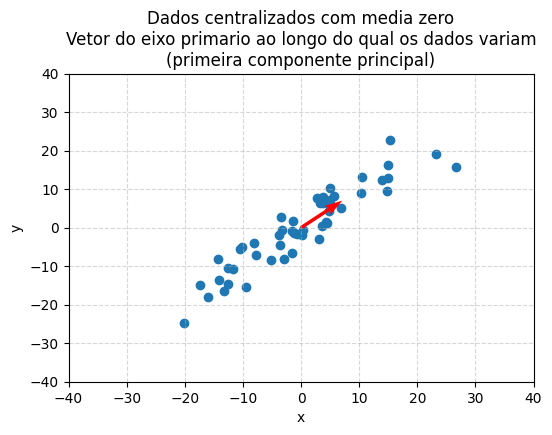

In [115]:
plt.figure(figsize=(6, 4))
plt.scatter(x_1, y_1)
plt.quiver(0, 0, direcao_maior_variacao[0]*10, direcao_maior_variacao[1]*10, # aumenta tamanho do vetor em 10x, apenas para facilitar a visualizacao
           angles='xy', scale_units='xy', scale=1, color="red")

plt.title("Dados centralizados com media zero\nVetor do eixo primario ao longo do qual os dados variam\n(primeira componente principal)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [110]:
from modulo_python_livro import scalar_multiply

def project(v: list, w: list) -> list:
    """
    Retorna a projecao de v sobre w
    """
    projection_length = dot(v, w)
    return scalar_multiply(projection_length, w)

def remove_projection_from_vector(v: list, w: list) -> list:
    """
    Projeta v em w e subtrai o resultado de v
    """
    return vector_subtract(v, project(v, w))

def remove_projection(data: list[list], w: list) -> list[list]:
    """
    Projeta cada ponto em w e subtrai o resultado de cada ponto
    """
    return [remove_projection_from_vector(v, w) for v in data]

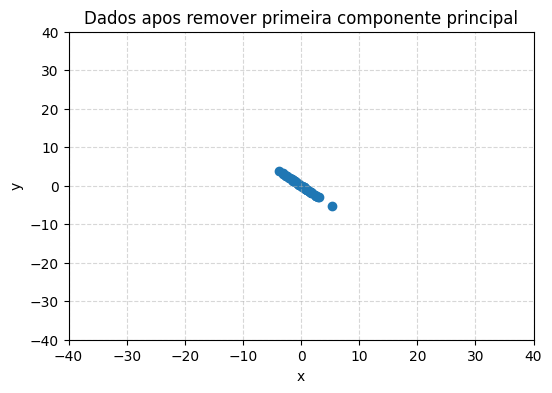

In [111]:
dados_projetados = remove_projection(dados_centralizados, direcao_maior_variacao)
x_2, y_2         = list(zip(*dados_projetados))

plt.figure(figsize=(6, 4))
plt.scatter(x_2, y_2)

plt.title("Dados apos remover primeira componente principal")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [113]:
# vetor da segunda componente principal
direcao_maior_variacao_2 = first_principal_component(dados_projetados)
direcao_maior_variacao_2

dv: 366.589: 100%|██████████| 100/100 [00:00<00:00, 726.39it/s]


[np.float64(-0.7036972570416363), np.float64(0.7104999440056821)]

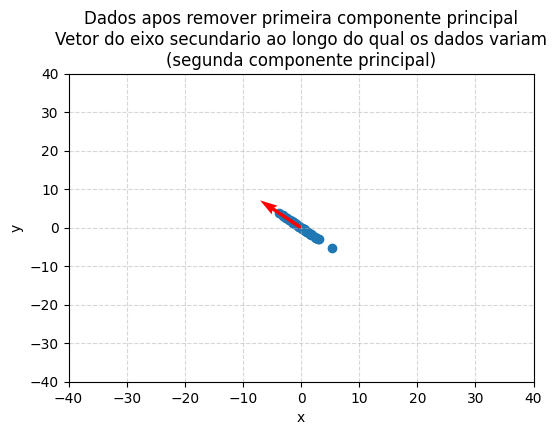

In [116]:
plt.figure(figsize=(6, 4))
plt.scatter(x_2, y_2)
plt.quiver(0, 0, direcao_maior_variacao_2[0]*10, direcao_maior_variacao_2[1]*10, # aumenta tamanho do vetor em 10x, apenas para facilitar a visualizacao
           angles='xy', scale_units='xy', scale=1, color="red")

plt.title("Dados apos remover primeira componente principal\nVetor do eixo secundario ao longo do qual os dados variam\n(segunda componente principal)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [117]:
# tamanho do vetor encontrado para segunda componente
magnitude(direcao_maior_variacao_2)

1.0

In [119]:
# encontra componentes principais, quantas forem passadas
def pca(data: list[list], num_components: int) -> list[list]:
    components = []
    for _ in range(num_components):
        component = first_principal_component(data)
        components.append(component)
        data = remove_projection(data, component)

    return components

components = pca(dados_centralizados, 2)
components

dv: 366.589: 100%|██████████| 100/100 [00:00<00:00, 647.35it/s]


[[np.float64(0.7103617627348822), np.float64(0.7038367467276706)],
 [np.float64(-0.7036972570416363), np.float64(0.7104999440056821)]]

In [121]:
direcao_maior_variacao

[np.float64(0.7103617627348822), np.float64(0.7038367467276706)]

In [120]:
direcao_maior_variacao_2

[np.float64(-0.7036972570416363), np.float64(0.7104999440056821)]

In [124]:
# reduz a dimensionalidade dos dados centralizados
# de acordo com a quantidade de componentes encontradas
def transform_vector(v: list, components: list[list]) -> list:
    return [dot(v, w) for w in components]

dados_transformados = [transform_vector(v, components) for v in dados_centralizados]

def transform(data: list[list], components: list[list]) -> list[list]:
    return [transform_vector(v, components) for v in data]

dados_transformados_2 = transform(dados_centralizados, components)

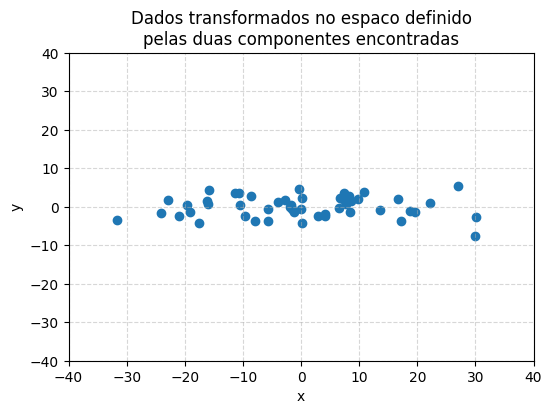

In [126]:
dados_transformados = transform(dados_centralizados, components)
x_3, y_3            = list(zip(*dados_transformados))

plt.figure(figsize=(6, 4))
plt.scatter(x_3, y_3)

plt.title("Dados transformados no espaco definido\npelas duas componentes encontradas")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

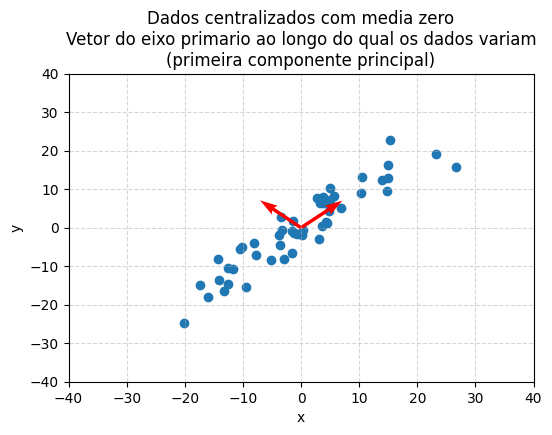

In [129]:
# duas componentes principais encontradas
plt.figure(figsize=(6, 4))
plt.scatter(x_1, y_1)
plt.quiver(0, 0, components[0][0]*10, components[0][1]*10, # aumenta tamanho do vetor em 10x, apenas para facilitar a visualizacao
           angles='xy', scale_units='xy', scale=1, color="red")
plt.quiver(0, 0, components[1][0]*10, components[1][1]*10, # aumenta tamanho do vetor em 10x, apenas para facilitar a visualizacao
           angles='xy', scale_units='xy', scale=1, color="red")

plt.title("Dados centralizados com media zero\nVetor do eixo primario ao longo do qual os dados variam\n(primeira componente principal)")
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-40,40)
plt.ylim(-40,40)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()